In [1]:
import re
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer

In [2]:
filename = "train.csv"
df = pd.read_csv(filename)
print(df.head())

      label                                             review
0  positive  best cheap GPS: The Garmin Etrex, at under $10...
1  positive  YOU MADE ME FEEL I WAS AYLA!: WHEN WILL #5 COM...
2  negative  So good we now buy Brother: Installing one of ...
3  positive  Powerful: Austin brings to life a part of the ...
4  positive  Tao terrific: This read is very informational ...


In [3]:
# Label distribution of reviews
print(f"Number of reviews:\n{df['label'].value_counts()}")

Number of reviews:
label
positive    17811
negative    17133
Name: count, dtype: int64


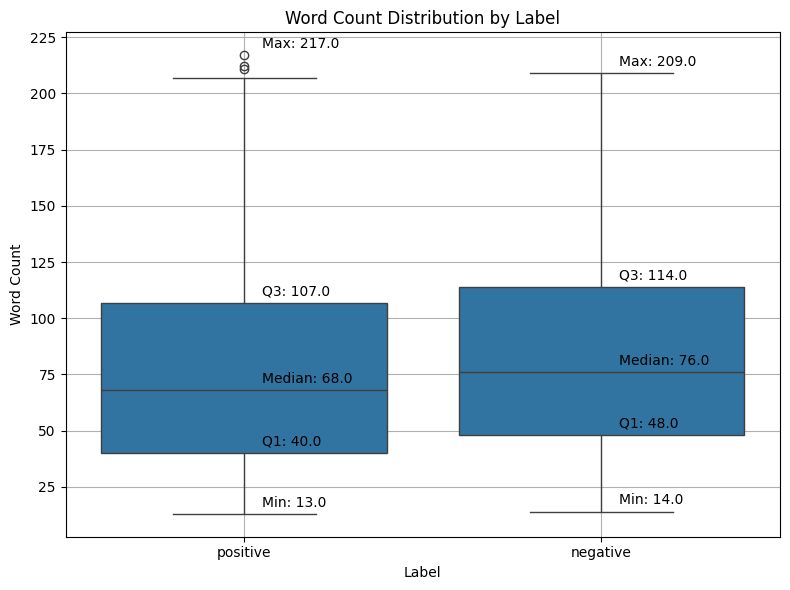

In [4]:
# Create word_count variable for each review
df["word_count"] = df["review"].apply(lambda x: len(str(x).split()))

# Box plot
plt.figure(figsize=(8, 6))
sns.boxplot(x='label', y='word_count', data=df)
plt.title('Word Count Distribution by Label')
plt.xlabel('Label')
plt.ylabel('Word Count')
plt.grid(True)

# Annotate statistics on the actual lines
labels = df['label'].unique()
for i, label in enumerate(labels):
    subset = df[df['label'] == label]['word_count']
    stats = {
        'Min': subset.min(),
        'Q1': subset.quantile(0.25),
        'Median': subset.median(),
        'Q3': subset.quantile(0.75),
        'Max': subset.max(),
    }
    x_pos = i + 0.05
    for stat_name, y_val in stats.items():
        plt.text(
            x=x_pos,
            y=y_val + 5,
            s=f'{stat_name}: {y_val:.1f}',
            va='center',
            ha='left',
            fontsize=10,
            color='black'
        )

plt.tight_layout()
plt.show()

We observe that the number of words, on average, in a negative review is slightly higher than a positive review. However, it should also be noted that there are several positive reviews that are outliers, with a very high number of words.

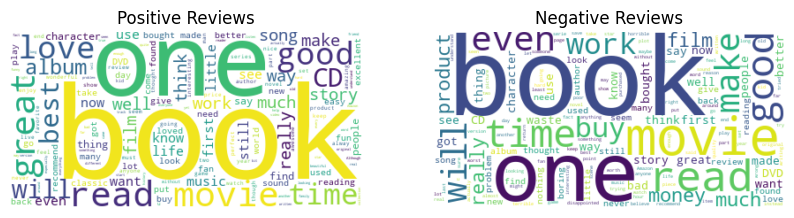

In [5]:
from wordcloud import WordCloud

# Word cloud visualization
positive_df = df[df["label"] == "positive"]
negative_df = df[df["label"] == "negative"]

text_pos = " ".join(positive_df['review'])
text_neg = " ".join(negative_df['review'])

wordcloud_pos = WordCloud(background_color='white').generate(text_pos)
wordcloud_neg = WordCloud(background_color='white').generate(text_neg)

plt.figure(figsize=(10,5))
plt.subplot(1, 2, 1)
plt.imshow(wordcloud_pos, interpolation='bilinear')
plt.axis('off')
plt.title('Positive Reviews')

plt.subplot(1, 2, 2)
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.axis('off')
plt.title('Negative Reviews')

plt.show()

In [6]:
# Get the stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
stop_words.update(['book', 'movie'])

# Word frequency analysis for positive reviews
positive_text = ' '.join(positive_df['review'].astype(str).tolist()) # combine all reviews into one string
positive_text = re.sub(r'[^a-zA-Z\s]', '', positive_text.lower())  # remove punctuation and lowercase
positive_words = [word for word in positive_text.split() if word not in stop_words] # tokenize words and remove stopwords
word_freq = Counter(positive_words)
freq_df = pd.DataFrame(word_freq.items(), columns=['Word', 'Frequency'])
freq_df = freq_df.sort_values(by='Frequency', ascending=False).reset_index(drop=True)

# Top 10 words associated with positive reviews
print(f"Top 10 words associated with positive reviews:\n{freq_df.head(10)}") 

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\xiang\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Top 10 words associated with positive reviews:
    Word  Frequency
0  great       8014
1    one       6823
2   good       5908
3   read       5564
4   like       4913
5   love       3590
6   best       3456
7  would       3251
8   time       3184
9   well       3027


In [7]:
# Word frequency analysis for negative reviews
negative_text = ' '.join(negative_df['review'].astype(str).tolist()) # combine all reviews into one string
negative_text = re.sub(r'[^a-zA-Z\s]', '', negative_text.lower())  # remove punctuation and lowercase
negative_words = [word for word in negative_text.split() if word not in stop_words] # tokenize words and remove stopwords
word_freq = Counter(negative_words)
freq_df = pd.DataFrame(word_freq.items(), columns=['Word', 'Frequency'])
freq_df = freq_df.sort_values(by='Frequency', ascending=False).reset_index(drop=True)

# Top 10 words associated with negative reviews
print(f"Top 10 words associated with negative reviews:\n{freq_df.head(10)}")

Top 10 words associated with negative reviews:
    Word  Frequency
0    one       6700
1   like       5531
2  would       4850
3   good       4230
4   dont       4134
5   read       4028
6    get       3590
7   time       3501
8   even       3081
9   much       2879


In positive reviews, we see frequent words include "great", "good", "like" and "love", which are all positive words that matches our expectations. However in negative reviews, interestingly similar words such as "like" and "good" appear frequently as well. One possible explanation is that these words appear in conjunction with "don't", which is another frequent word in negative reviews. Then the phrase "don't like" will produce a negative sentiment which matches our expectations.

This motivates a bigram frequency analysis instead of simply doing unigram/word frequency analysis. Bigram analysis will allow us to possibly identify reasons for a positive review or negative review, in a manner than unigram/word frequency analysis is unable to do so.

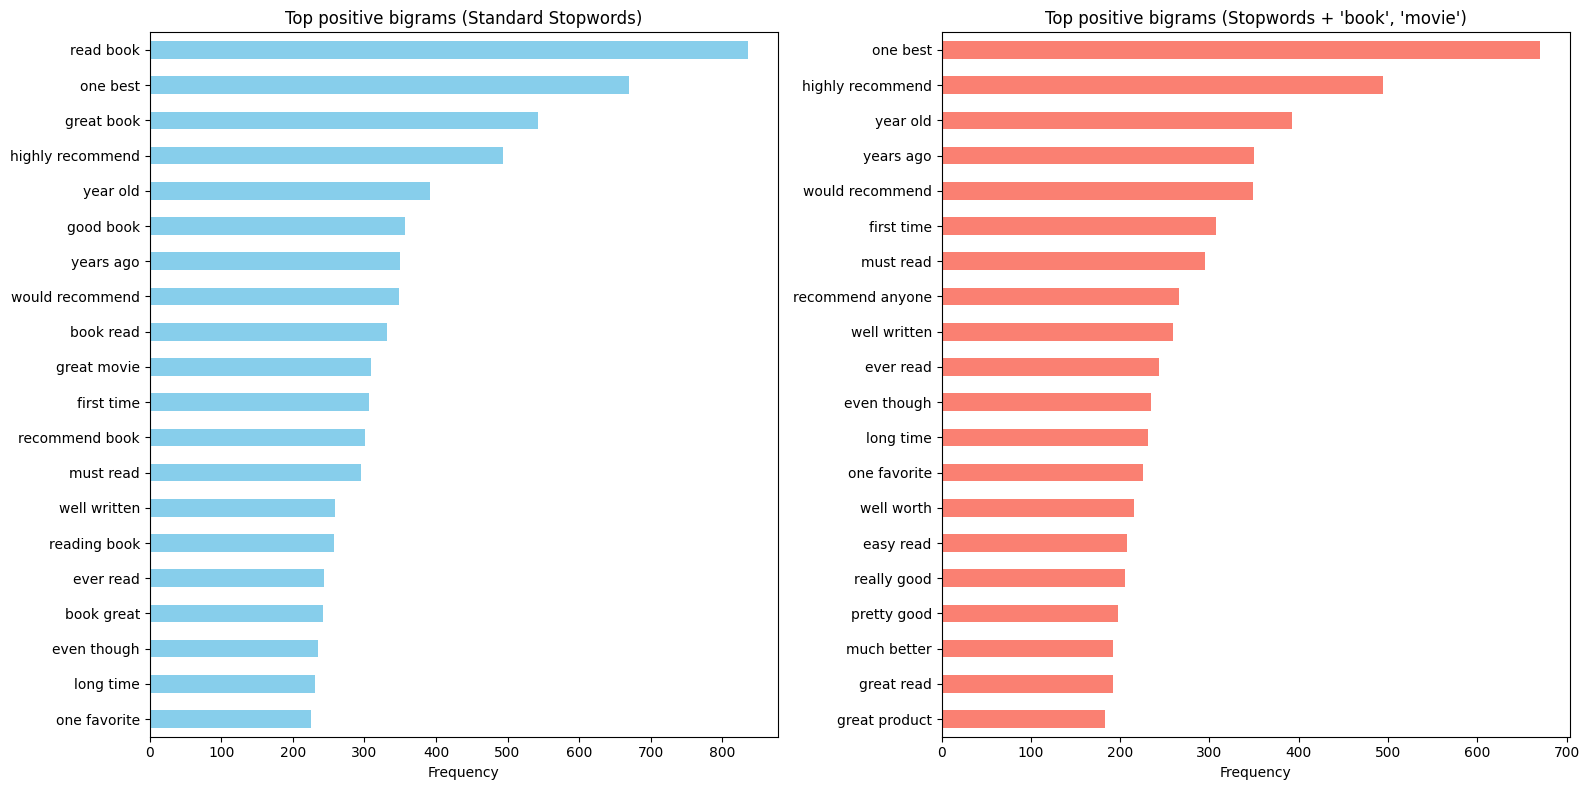

In [8]:
# Bigram analysis for positive reviews

stop_words = set(stopwords.words('english'))

# First vectorizer (original stopwords)
vectorizer1 = CountVectorizer(ngram_range=(2, 2), stop_words=list(stop_words), max_features=20)
X_ngrams1 = vectorizer1.fit_transform(positive_df['review'])
bigrams1 = pd.Series(np.array(X_ngrams1.sum(axis=0)).flatten(), index=vectorizer1.get_feature_names_out()).sort_values()

# Second vectorizer (stopwords + 'book', 'movie')
stop_words.update(['book', 'movie'])
vectorizer2 = CountVectorizer(ngram_range=(2, 2), stop_words=list(stop_words), max_features=20)
X_ngrams2 = vectorizer2.fit_transform(positive_df['review'])
bigrams2 = pd.Series(np.array(X_ngrams2.sum(axis=0)).flatten(), index=vectorizer2.get_feature_names_out()).sort_values()

# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# First plot
bigrams1.plot(kind='barh', ax=axes[0], color='skyblue')
axes[0].set_title('Top positive bigrams (Standard Stopwords)')
axes[0].set_xlabel('Frequency')

# Second plot
bigrams2.plot(kind='barh', ax=axes[1], color='salmon')
axes[1].set_title("Top positive bigrams (Stopwords + 'book', 'movie')")
axes[1].set_xlabel('Frequency')

plt.tight_layout()
plt.show()

The plots show the 20 most common bigrams in positive reviews. The left plot was created after removing standard stop words and the right plot was created after removing standard stop words and the words "book" and "movie". The reasoning is because we want to try to identify bigrams that are not a 1-word description of the product, like "good book" or "great movie" which are not very informative. 
From the plots, we can see that some reasons for a product to get a positive review include "well written" which means the product has a good quality, and "easy read" which means the product is accessible to everyone.

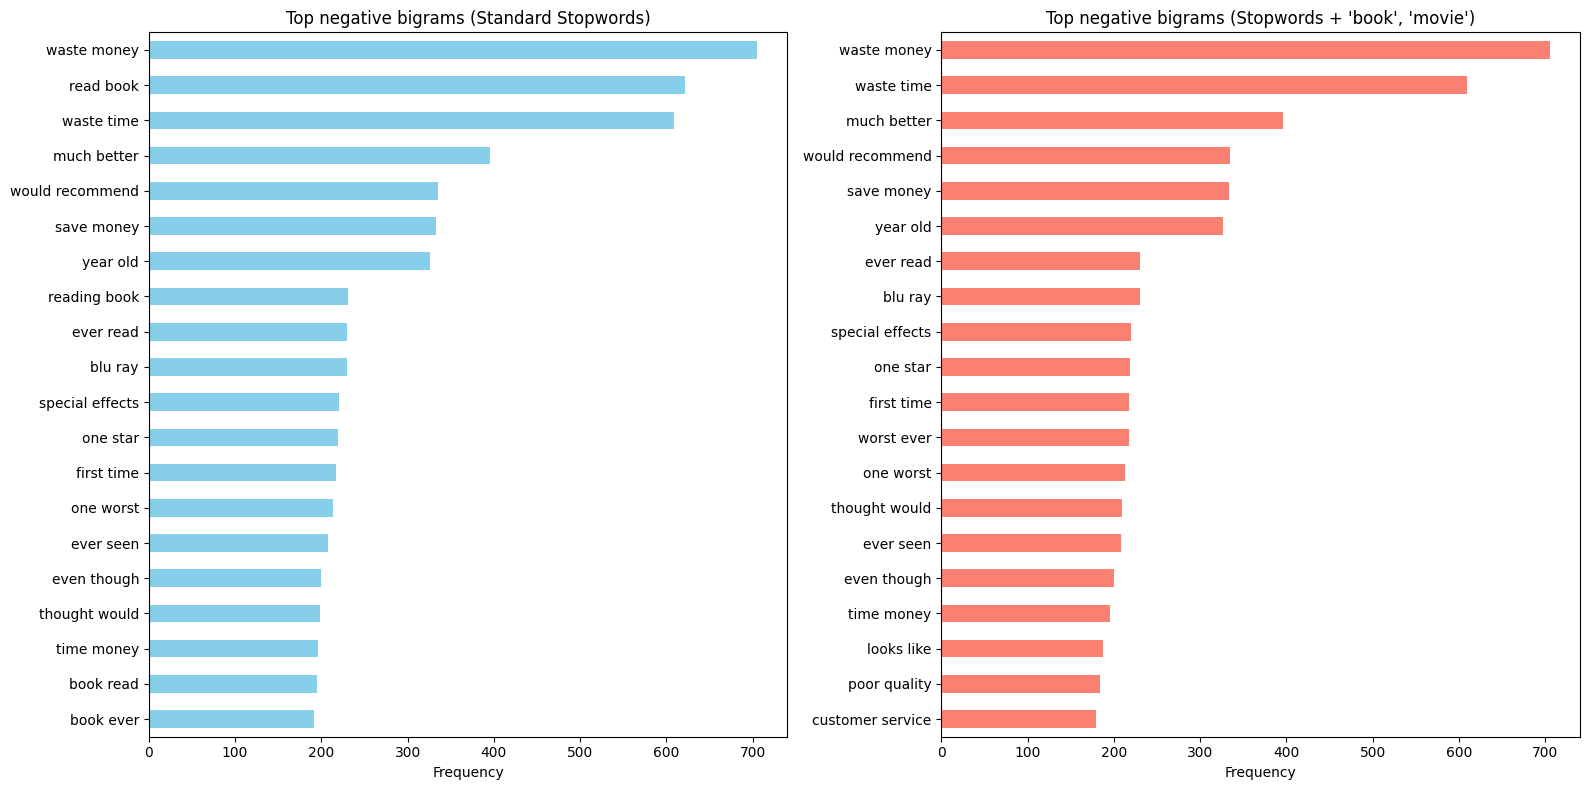

In [9]:
# Bigram analysis for negative reviews

stop_words = set(stopwords.words('english'))

# First vectorizer (original stopwords)
vectorizer1 = CountVectorizer(ngram_range=(2, 2), stop_words=list(stop_words), max_features=20)
X_ngrams1 = vectorizer1.fit_transform(negative_df['review'])
bigrams1 = pd.Series(np.array(X_ngrams1.sum(axis=0)).flatten(), index=vectorizer1.get_feature_names_out()).sort_values()

# Second vectorizer (stopwords + 'book', 'movie')
stop_words.update(['book', 'movie'])
vectorizer2 = CountVectorizer(ngram_range=(2, 2), stop_words=list(stop_words), max_features=20)
X_ngrams2 = vectorizer2.fit_transform(negative_df['review'])
bigrams2 = pd.Series(np.array(X_ngrams2.sum(axis=0)).flatten(), index=vectorizer2.get_feature_names_out()).sort_values()

# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# First plot
bigrams1.plot(kind='barh', ax=axes[0], color='skyblue')
axes[0].set_title('Top negative bigrams (Standard Stopwords)')
axes[0].set_xlabel('Frequency')

# Second plot
bigrams2.plot(kind='barh', ax=axes[1], color='salmon')
axes[1].set_title("Top negative bigrams (Stopwords + 'book', 'movie')")
axes[1].set_xlabel('Frequency')

plt.tight_layout()
plt.show()

The plots show the 20 most common bigrams in negative reviews. Similarly, the left plot was created after removing standard stop words and the right plot was created after removing standard stop words and the words "book" and "movie". There are a plethora of possible reasons for a negative review, such as "waste money" which means the product is too expensive, or "waste time" which means the duration of the book or movie is too long. Interstingly, "customer service" and "special effects" were also identified to be the key areas that are not up to standard.